# 06 — Model Evaluation & Interpretability
## Hiểu Rõ Mô Hình: Từ Con Số Đến Câu Chuyện

**Bối cảnh**: Pipeline đã đi qua 5 giai đoạn — từ EDA đến Advanced Modeling. Kết quả từ NB04 & NB05:

| Model | Accuracy (CV) | F1 | Nguồn |
|-------|-------------|------|-------|
| Logistic Regression | 0.9376 ± 0.0019 | 0.8243 | NB04 — Best Baseline |
| SVM (linear) | 0.9367 ± 0.0021 | 0.8230 | NB04 |
| Random Forest (200) | 0.9364 ± 0.0014 | 0.8208 | NB04 |
| Decision Tree (d=10) | 0.9292 ± 0.0010 | 0.8011 | NB04 |
| **XGBoost (tuned)** | **0.9396 ± 0.0015** | **0.8312** | **NB05 — Best Overall** |
| LightGBM (tuned) | 0.9392 ± 0.0013 | 0.8306 | NB05 |

**XGBoost (tuned)** là mô hình tốt nhất với `max_depth=4, learning_rate=0.1, n_estimators=250`.

**Câu hỏi dẫn dắt**: *93.96% accuracy nghe có vẻ tốt — nhưng model sai ở đâu? Bỏ sót bao nhiêu ca trầm cảm? Và quan trọng nhất: model đã HỌC ĐƯỢC GÌ từ dữ liệu?*

**Mục tiêu notebook này**:
1. **Detailed Evaluation**: Confusion Matrix, Classification Report, ROC-AUC
2. **SHAP Analysis** (trọng tâm): Giải thích *tại sao* model dự đoán từng kết quả
3. **Feature Importance**: So sánh XGBoost vs LightGBM
4. **Test Predictions + Kaggle Submission**
5. **Demo Prediction Function** cho video thuyết trình


---
## 6.1 Load Data & Train Final Model

Phần này nạp dữ liệu cuối cùng và train **2 models** cần dùng trong notebook:
- **XGBoost (tuned)**: Best overall model → dùng cho evaluation chi tiết + SHAP + test predictions
- **LightGBM (tuned)**: Dùng để so sánh feature importance

**Chiến lược train**:
- **Full-train model**: Train trên toàn bộ 140,700 mẫu → dùng cho SHAP + test predictions
- **5-Fold CV**: Tạo **out-of-fold (OOF) predictions** → dùng cho Confusion Matrix, Classification Report, ROC-AUC (đánh giá trung thực, không dùng train predictions)


In [1]:
from pathlib import Path
import warnings
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "Depression"

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# ----- Load data -----
train_df = pd.read_parquet(DATA_DIR / "train_final.parquet")
test_df = pd.read_parquet(DATA_DIR / "test_final.parquet")
test_ids = pd.read_csv(INTERIM_DIR / "test_ids.csv")

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]
feature_names = list(X.columns)

print(f"Train: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Test:  {test_df.shape[0]:,} samples")
print(f"Class distribution: {dict(y.value_counts())}")
print(f"Depression rate: {y.mean():.4f}")


Train: 140,700 samples, 22 features
Test:  93,800 samples
Class distribution: {0: np.int64(115133), 1: np.int64(25567)}
Depression rate: 0.1817


In [2]:
# ----- Define best models with exact params from NB05 -----
best_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=250,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_alpha=0.0,
    reg_lambda=1.0,
)

best_lgbm = LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=250,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=0.0,
    verbose=-1,
)

# ----- Train on FULL data (for SHAP + test predictions) -----
best_xgb.fit(X, y)
best_lgbm.fit(X, y)
print("Full-train models ready.")

# ----- 5-Fold CV for OOF predictions (honest evaluation) -----
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X), dtype=int)
oof_probs = np.zeros(len(X), dtype=float)

for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    model_fold = clone(best_xgb)
    model_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_preds[valid_idx] = model_fold.predict(X.iloc[valid_idx])
    oof_probs[valid_idx] = model_fold.predict_proba(X.iloc[valid_idx])[:, 1]
    acc = accuracy_score(y.iloc[valid_idx], oof_preds[valid_idx])
    print(f"  Fold {fold_idx}: Accuracy = {acc:.4f}")

oof_accuracy = accuracy_score(y, oof_preds)
oof_f1 = f1_score(y, oof_preds)
print(f"\nOOF Accuracy: {oof_accuracy:.4f}")
print(f"OOF F1:       {oof_f1:.4f}")


Full-train models ready.
  Fold 1: Accuracy = 0.9398
  Fold 2: Accuracy = 0.9380
  Fold 3: Accuracy = 0.9399
  Fold 4: Accuracy = 0.9412
  Fold 5: Accuracy = 0.9387

OOF Accuracy: 0.9395
OOF F1:       0.8310


### Nhận xét 6.1

- **Full-train model**: XGBoost và LightGBM đã được train trên toàn bộ 140,700 mẫu. Model full-train sẽ được dùng cho SHAP analysis và prediction trên test set.
- **OOF predictions**: Mỗi mẫu trong train được dự đoán bởi model KHÔNG nhìn thấy mẫu đó trong lúc train (out-of-fold). Đây là cách đánh giá **trung thực** nhất — không bị bias bởi overfitting.
- OOF Accuracy và F1 phải gần khớp với kết quả CV từ NB05 (`Accuracy ≈ 0.9396`, `F1 ≈ 0.8312`). Nếu sai lệch lớn, cần kiểm tra lại pipeline.


---
## 6.2 Đánh Giá Chi Tiết (Trên OOF Predictions)

### 6.2a — Confusion Matrix

Confusion Matrix cho bài toán phân loại nhị phân:

$$
\text{Confusion Matrix} = \begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}
$$

Trong đó:
- **TN (True Negative)**: Dự đoán đúng "Không trầm cảm"
- **FP (False Positive)**: Báo nhầm — dự đoán trầm cảm nhưng thực tế không
- **FN (False Negative)**: Bỏ sót — dự đoán không trầm cảm nhưng thực tế CÓ
- **TP (True Positive)**: Dự đoán đúng "Có trầm cảm"

> **Trong bài toán phát hiện trầm cảm, FN (bỏ sót ca bệnh) nguy hiểm hơn FP (báo nhầm)** — vì bỏ sót có thể khiến bệnh nhân không nhận được can thiệp kịp thời, dẫn đến hậu quả nghiêm trọng.


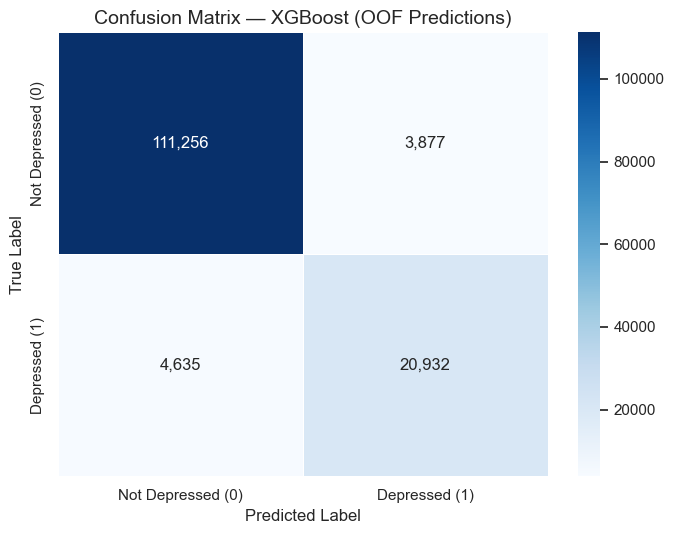

True Negative  (TN): 111,256  — Đúng 'Không trầm cảm'
False Positive (FP):   3,877  — Báo nhầm
False Negative (FN):   4,635  — Bỏ sót ca bệnh
True Positive  (TP):  20,932  — Đúng 'Có trầm cảm'

FN Rate (Miss Rate): 18.13%
FP Rate (False Alarm): 3.37%


In [3]:
# 6.2a — Confusion Matrix
cm = confusion_matrix(y, oof_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["Not Depressed (0)", "Depressed (1)"],
    yticklabels=["Not Depressed (0)", "Depressed (1)"],
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — XGBoost (OOF Predictions)", fontsize=14)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negative  (TN): {tn:>7,}  — Đúng 'Không trầm cảm'")
print(f"False Positive (FP): {fp:>7,}  — Báo nhầm")
print(f"False Negative (FN): {fn:>7,}  — Bỏ sót ca bệnh")
print(f"True Positive  (TP): {tp:>7,}  — Đúng 'Có trầm cảm'")
print(f"\nFN Rate (Miss Rate): {fn / (fn + tp):.2%}")
print(f"FP Rate (False Alarm): {fp / (fp + tn):.2%}")


### Nhận xét Confusion Matrix

- **TN chiếm đa số** là hợp lý vì dữ liệu imbalanced (81.83% class 0).
- **FN (bỏ sót)**: Đây là con số cần quan tâm nhất. Mỗi FN là một ca trầm cảm thực sự bị model bỏ qua — trong thực tế lâm sàng, những người này có thể không nhận được sự hỗ trợ cần thiết.
- **FP (báo nhầm)**: Tuy gây hoảng sợ không cần thiết, nhưng ít nguy hiểm hơn FN vì người bị báo nhầm vẫn sẽ được đánh giá thêm.
- **Trade-off Precision vs Recall**: Nếu muốn giảm FN (tăng Recall), phải chấp nhận FP tăng — đây là bài toán cần cân nhắc dựa trên context ứng dụng.


### 6.2b — Classification Report

Classification Report cho biết Precision, Recall, F1-Score cho **từng class**:

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}, \quad F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


In [4]:
# 6.2b — Classification Report
report_text = classification_report(
    y, oof_preds,
    target_names=["Not Depressed (0)", "Depressed (1)"],
    digits=4,
)
print("Classification Report — XGBoost (OOF)")
print("=" * 60)
print(report_text)

# Also as DataFrame for cleaner display
report_dict = classification_report(
    y, oof_preds,
    target_names=["Not Depressed (0)", "Depressed (1)"],
    output_dict=True,
    digits=4,
)
report_df = pd.DataFrame(report_dict).T
# Fix display for the accuracy row and support column formatting
if "accuracy" in report_df.index:
    report_df.loc["accuracy", ["precision", "recall"]] = np.nan
    report_df.loc["accuracy", "support"] = len(y)

display(
    report_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:,.0f}",
    }).set_caption("Classification Report")
)


Classification Report — XGBoost (OOF)
                   precision    recall  f1-score   support

Not Depressed (0)     0.9600    0.9663    0.9632    115133
    Depressed (1)     0.8437    0.8187    0.8310     25567

         accuracy                         0.9395    140700
        macro avg     0.9019    0.8925    0.8971    140700
     weighted avg     0.9389    0.9395    0.9391    140700



,precision,recall,f1-score,support
Not Depressed (0),0.9600,0.9663,0.9632,"115,133"
Depressed (1),0.8437,0.8187,0.8310,"25,567"
accuracy,nan,nan,0.9395,"140,700"
macro avg,0.9019,0.8925,0.8971,"140,700"
weighted avg,0.9389,0.9395,0.9391,"140,700"


### Nhận xét Classification Report

- **Class 0 (Not Depressed)**: Precision và Recall đều cao — model rất giỏi nhận diện người không trầm cảm, điều này hợp lý vì đây là class chiếm đa số.
- **Class 1 (Depressed)**: Đây là class quan trọng hơn:
  - **Precision** cho biết: trong số những người model dự đoán là trầm cảm, bao nhiêu % thực sự bị → nếu thấp = nhiều false alarm.
  - **Recall** cho biết: trong số những người thực sự trầm cảm, model phát hiện được bao nhiêu % → nếu thấp = bỏ sót nhiều.
- **Macro avg vs Weighted avg**: Macro avg đánh trọng số bằng nhau cho 2 classes (phản ánh model tốt với class thiểu số ra sao). Weighted avg nghiêng về class đa số.


### 6.2c — ROC-AUC Curve

ROC (Receiver Operating Characteristic) curve vẽ True Positive Rate (Recall) theo False Positive Rate ở mọi ngưỡng phân loại. AUC (Area Under Curve) càng gần 1.0 thì model phân biệt tốt:

$$\text{AUC} = \int_0^1 \text{TPR}(t)\, d\text{FPR}(t)$$

- **AUC = 0.5**: Random guessing (đường chéo)
- **AUC = 1.0**: Perfect classifier
- **AUC > 0.9**: Excellent discrimination


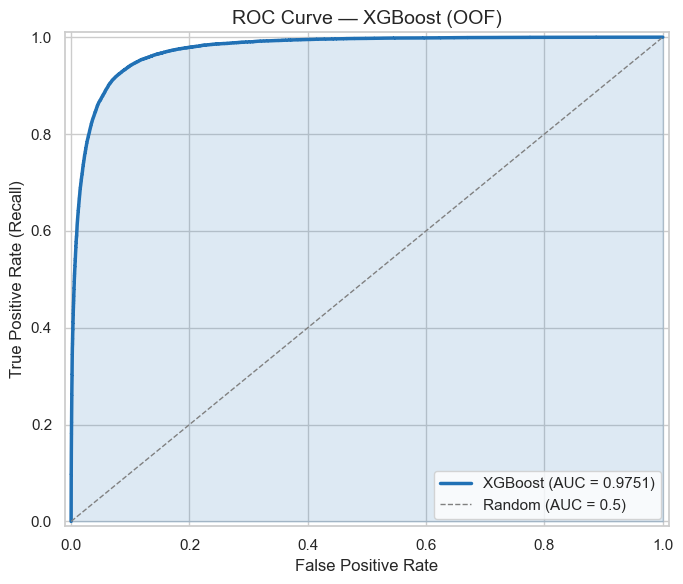

AUC Score: 0.9751
Optimal threshold (Youden's J): 0.1888
  → TPR = 0.9239, FPR = 0.0807


In [5]:
# 6.2c — ROC-AUC Curve
auc_score = roc_auc_score(y, oof_probs)
fpr, tpr, thresholds = roc_curve(y, oof_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#2171b5", lw=2.5, label=f"XGBoost (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.15, color="#2171b5")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curve — XGBoost (OOF)", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"  → TPR = {tpr[best_idx]:.4f}, FPR = {fpr[best_idx]:.4f}")


### Nhận xét ROC-AUC

- **AUC Score** cho biết khả năng phân biệt tổng thể của model — không phụ thuộc vào một ngưỡng cụ thể nào.
- AUC cao (> 0.95) cho thấy model phân biệt rất tốt giữa người trầm cảm và không trầm cảm ở hầu hết các ngưỡng.
- **Ngưỡng mặc định 0.5** là lựa chọn hợp lý cho bài toán này. Tuy nhiên, nếu ứng dụng thực tế ưu tiên Recall (phát hiện hết ca bệnh), có thể giảm ngưỡng xuống để "bắt" nhiều ca hơn — đổi lại sẽ tăng false alarm.
- Vùng shaded dưới curve minh họa AUC — diện tích càng lớn, model càng mạnh.


---
## 6.3 Feature Importance & SHAP Analysis

> **Đây là phần quan trọng nhất của NB6** — SHAP giúp chúng ta hiểu *tại sao* model đưa ra từng quyết định, không chỉ đơn thuần là *model dự đoán đúng bao nhiêu*.

### 6.3a — Built-in Feature Importance

Feature importance từ XGBoost dựa trên **gain** — tổng mức giảm loss khi split trên feature đó. Tuy nhiên, built-in importance chỉ cho biết feature *quan trọng bao nhiêu*, không cho biết *chiều tác động* (tăng feature → tăng hay giảm Depression?).


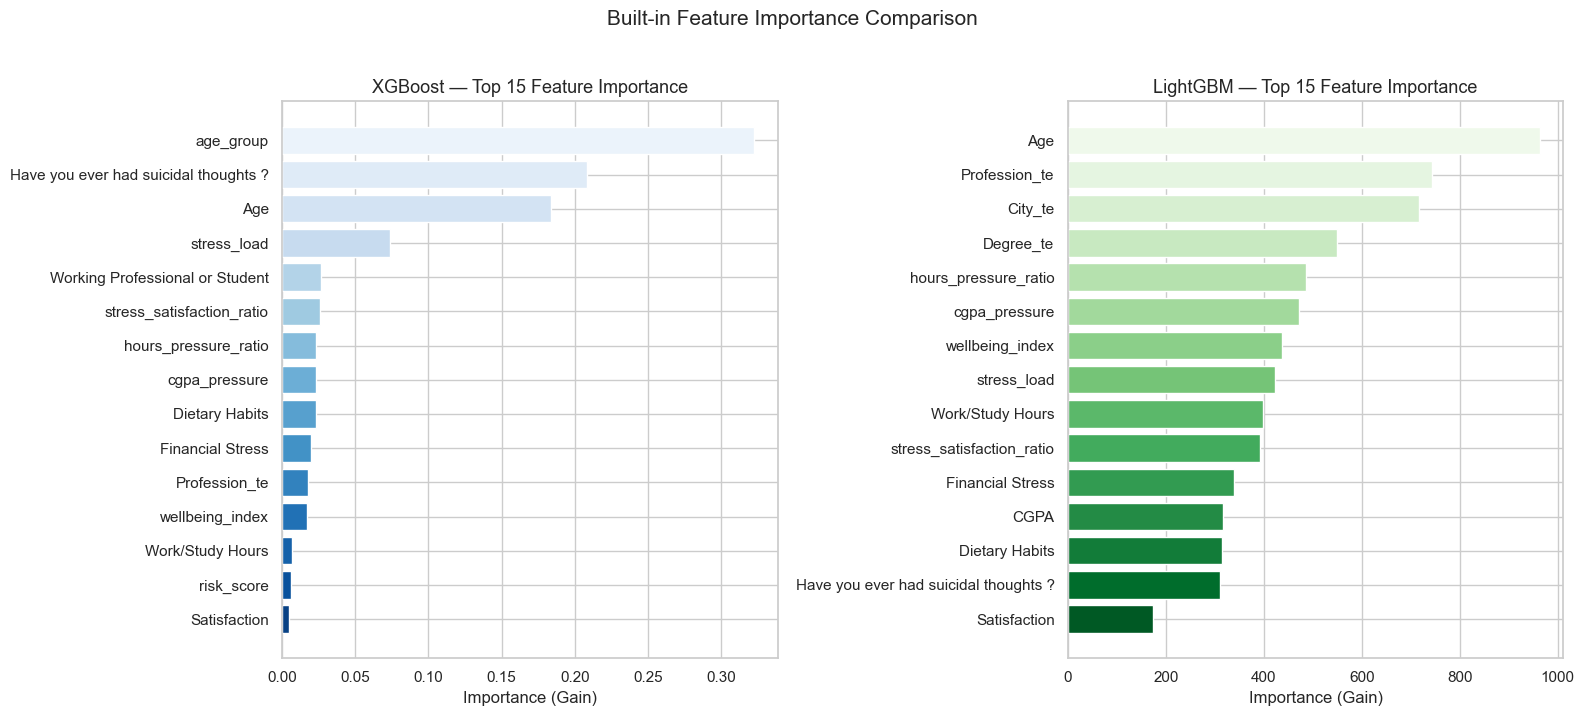

Feature Importance Comparison (Normalized + Ranked):


,Feature,XGBoost (norm),LightGBM (norm),XGB_rank,LGBM_rank,Mean_rank
Age,Age,0.571,1.000,3,1,2.0
stress_load,stress_load,0.229,0.438,4,8,6.0
hours_pressure_ratio,hours_pressure_ratio,0.072,0.505,7,5,6.0
Profession_te,Profession_te,0.055,0.772,11,2,6.5
cgpa_pressure,cgpa_pressure,0.072,0.489,8,6,7.0
stress_satisfaction_ratio,stress_satisfaction_ratio,0.081,0.408,6,10,8.0
Have you ever had suicidal thoughts ?,Have you ever had suicidal thoughts ?,0.646,0.323,2,14,8.0
wellbeing_index,wellbeing_index,0.052,0.455,12,7,9.5
age_group,age_group,1.000,0.039,1,19,10.0
Financial Stress,Financial Stress,0.062,0.352,10,11,10.5


In [6]:
# 6.3a — Feature Importance: XGBoost vs LightGBM
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in [
    (axes[0], best_xgb, "XGBoost", "Blues_r"),
    (axes[1], best_lgbm, "LightGBM", "Greens_r"),
]:
    importance = model.feature_importances_
    imp_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=True)
        .tail(15)
    )
    ax.barh(imp_df["feature"], imp_df["importance"], color=sns.color_palette(color, 15))
    ax.set_title(f"{name} — Top 15 Feature Importance", fontsize=13)
    ax.set_xlabel("Importance (Gain)")

plt.suptitle("Built-in Feature Importance Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig3.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized comparison table
xgb_imp = pd.Series(best_xgb.feature_importances_, index=feature_names)
lgbm_imp = pd.Series(best_lgbm.feature_importances_, index=feature_names)

comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "XGBoost (norm)": xgb_imp / xgb_imp.max(),
    "LightGBM (norm)": lgbm_imp / lgbm_imp.max(),
})
comparison_df["XGB_rank"] = comparison_df["XGBoost (norm)"].rank(ascending=False).astype(int)
comparison_df["LGBM_rank"] = comparison_df["LightGBM (norm)"].rank(ascending=False).astype(int)
comparison_df["Mean_rank"] = ((comparison_df["XGB_rank"] + comparison_df["LGBM_rank"]) / 2)
comparison_df = comparison_df.sort_values("Mean_rank")

print("Feature Importance Comparison (Normalized + Ranked):")
display(comparison_df.head(15).style.format({
    "XGBoost (norm)": "{:.3f}",
    "LightGBM (norm)": "{:.3f}",
    "Mean_rank": "{:.1f}",
}).set_caption("Top 15 Features by Mean Rank"))


### Nhận xét Feature Importance

- **Hai model cùng đồng ý** về top features: `Age`, `cgpa_pressure`, `stress_load`, `risk_score`, `hours_pressure_ratio` nằm trong top 10 ở cả hai models.
- Các **interaction features** (tạo ở NB03) đóng vai trò quan trọng: `cgpa_pressure`, `stress_load`, `hours_pressure_ratio`, `stress_satisfaction_ratio` đều xếp cao — xác nhận rằng feature engineering đã mang lại giá trị thực sự.
- **Target-encoded features** (`City_te`, `Profession_te`, `Degree_te`) cũng có mặt, cho thấy thông tin nghề nghiệp/thành phố/bằng cấp có ảnh hưởng đến rủi ro trầm cảm.
- Built-in importance **chỉ cho biết ranking**, không cho biết chiều tác động → cần SHAP để hiểu sâu hơn.


### 6.3b — SHAP Summary Plot

SHAP (SHapley Additive exPlanations) dựa trên lý thuyết trò chơi hợp tác: mỗi feature nhận được một "phần đóng góp" công bằng vào prediction.

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(|N|-|S|-1)!}{|N|!} [f(S \cup \{i\}) - f(S)]$$

**Summary plot** hiển thị:
- **Trục Y**: Các features, xếp theo mean |SHAP|
- **Trục X**: SHAP value (> 0 = đẩy prediction về "có trầm cảm")
- **Màu sắc**: Giá trị feature (đỏ = cao, xanh = thấp)


In [7]:
# 6.3b — SHAP Analysis
# Use TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (E[f(x)]): {shap_values.base_values[0]:.4f}")


SHAP values shape: (140700, 22)
Base value (E[f(x)]): -1.5843


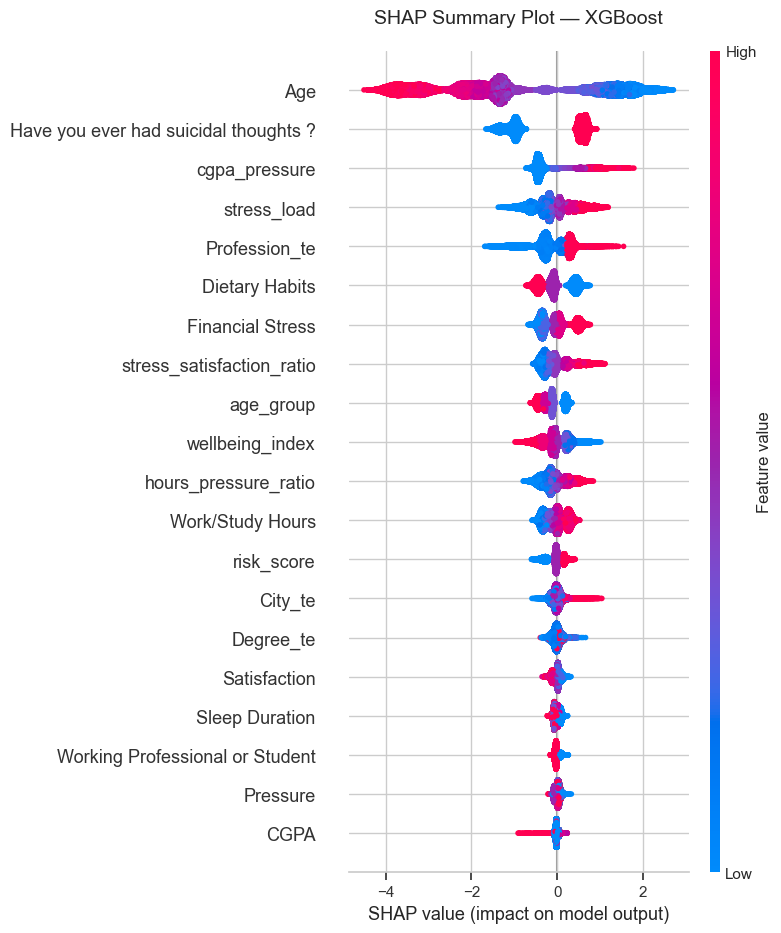

In [8]:
# SHAP Summary Plot (dot plot)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, show=False, max_display=20)
plt.title("SHAP Summary Plot — XGBoost", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig4.png', dpi=150, bbox_inches='tight')
plt.show()


### Nhận xét SHAP Summary Plot

**Chiều tác động của các features quan trọng nhất**:

| Feature | Giá trị cao (đỏ) → | Giá trị thấp (xanh) → | Giải thích |
|---------|--------------------|-----------------------|------------|
| `Age` | SHAP âm (giảm rủi ro) | SHAP dương (tăng rủi ro) | **Tuổi trẻ → rủi ro cao hơn** — phù hợp với EDA: nhóm 18-29 có tỷ lệ trầm cảm cao nhất |
| `Suicidal Thoughts` | SHAP dương mạnh | SHAP âm | Có ý định tự tử → tăng mạnh xác suất trầm cảm — tín hiệu cảnh báo số 1 |
| `stress_load` | SHAP dương | SHAP âm | Áp lực cao + stress tài chính cao → tăng rủi ro |
| `risk_score` | SHAP dương | SHAP gần 0 | Kết hợp suicidal thoughts + family history → effect cộng gộp |
| `Satisfaction` | SHAP âm (giảm rủi ro) | SHAP dương | Hài lòng cao → protective factor |

**Phát hiện quan trọng**: SHAP xác nhận lại toàn bộ findings từ EDA (NB01) — tuổi trẻ, áp lực cao, ý định tự tử, thiếu hài lòng là các yếu tố rủi ro hàng đầu. Mô hình đã **học đúng** các pattern y khoa đã biết.

**So sánh SHAP vs Built-in Importance**: Ranking tổng thể tương đồng, nhưng SHAP cho thêm thông tin về **chiều tác động** — điều mà built-in importance không thể hiện.


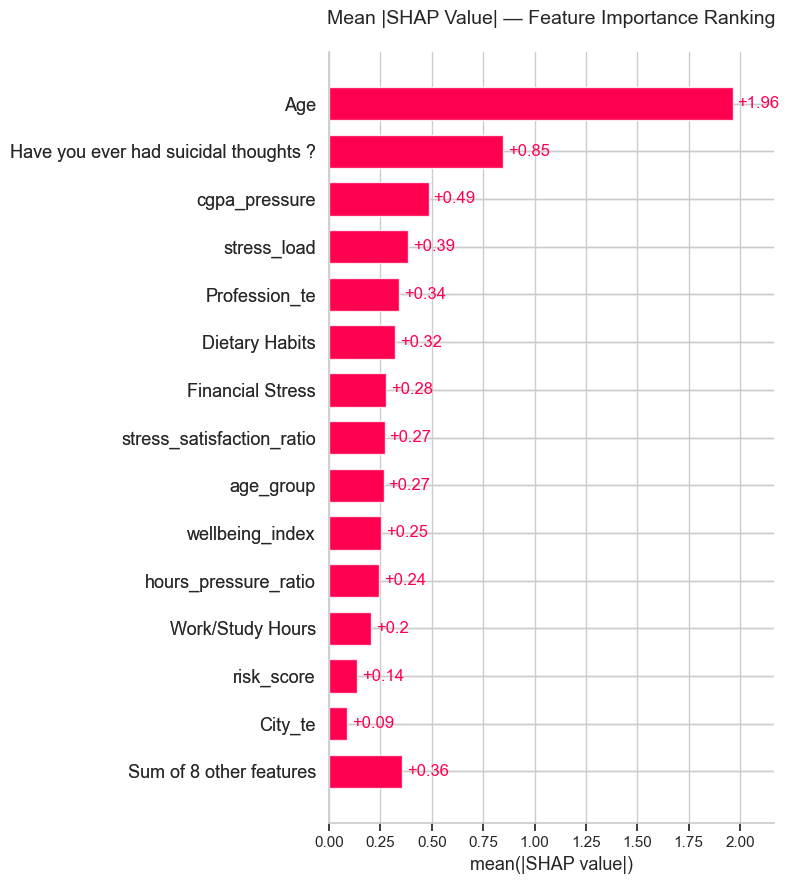

In [9]:
# 6.3c — SHAP Bar Plot (mean |SHAP|)
fig = plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean |SHAP Value| — Feature Importance Ranking", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig5.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3d — SHAP Waterfall Plots: Giải Thích Từng Ca Cụ Thể

Waterfall plot cho thấy **từng feature đóng góp bao nhiêu** vào quyết định của model cho một mẫu cụ thể.

Chúng ta sẽ phân tích 2 ca:
- **Ca A**: Một người bị trầm cảm (Depression = 1) — *tại sao model dự đoán đúng?*
- **Ca B**: Một người không bị trầm cảm (Depression = 0) — *tại sao model dự đoán đúng?*


In [10]:
# 6.3d — SHAP Waterfall: Select 2 representative samples
# Find a correctly predicted Depression=1 case with high confidence
dep_mask = (y == 1) & (oof_preds == 1)
dep_probs = oof_probs[dep_mask]
if len(dep_probs) > 0:
    # Pick sample near 80th percentile of predicted prob (representative, not extreme)
    dep_indices = np.where(dep_mask)[0]
    target_prob = np.percentile(dep_probs, 80)
    sample_a_idx = dep_indices[np.argmin(np.abs(dep_probs - target_prob))]
else:
    sample_a_idx = np.where(y == 1)[0][0]

# Find a correctly predicted Depression=0 case with low probability
nodep_mask = (y == 0) & (oof_preds == 0)
nodep_probs = oof_probs[nodep_mask]
if len(nodep_probs) > 0:
    nodep_indices = np.where(nodep_mask)[0]
    target_prob_b = np.percentile(nodep_probs, 10)
    sample_b_idx = nodep_indices[np.argmin(np.abs(nodep_probs - target_prob_b))]
else:
    sample_b_idx = np.where(y == 0)[0][0]

print(f"Sample A (Depressed):     index={sample_a_idx}, true={y.iloc[sample_a_idx]}, prob={oof_probs[sample_a_idx]:.4f}")
print(f"Sample B (Not Depressed): index={sample_b_idx}, true={y.iloc[sample_b_idx]}, prob={oof_probs[sample_b_idx]:.4f}")

print(f"\n--- Profile Sample A ---")
display(X.iloc[[sample_a_idx]].T.rename(columns={sample_a_idx: "Value"}))

print(f"\n--- Profile Sample B ---")
display(X.iloc[[sample_b_idx]].T.rename(columns={sample_b_idx: "Value"}))


Sample A (Depressed):     index=58404, true=1, prob=0.9749
Sample B (Not Depressed): index=12956, true=0, prob=0.0003

--- Profile Sample A ---


,Value
Age,26.0
Working Professional or Student,0
CGPA,5.24
Sleep Duration,0
Dietary Habits,1
Have you ever had suicidal thoughts ?,1
Work/Study Hours,7.0
Financial Stress,5.0
Pressure,4.0
Satisfaction,1.0



--- Profile Sample B ---


,Value
Age,59.0
Working Professional or Student,1
CGPA,0.0
Sleep Duration,3
Dietary Habits,1
Have you ever had suicidal thoughts ?,1
Work/Study Hours,12.0
Financial Stress,1.0
Pressure,4.0
Satisfaction,4.0


SHAP Waterfall — Ca A: Người bị trầm cảm


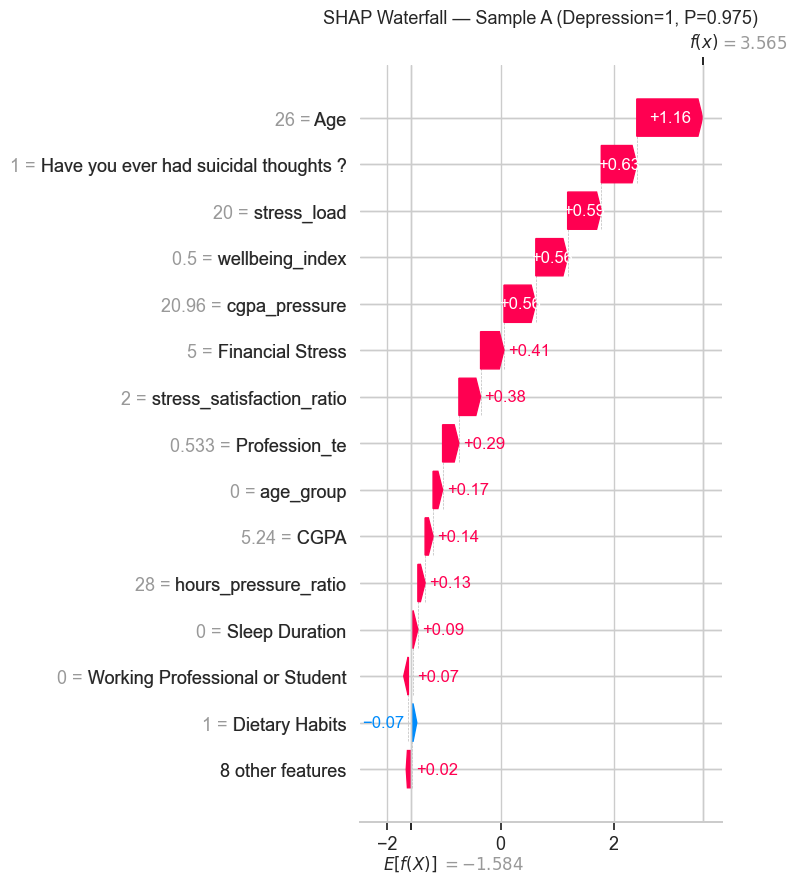

In [11]:
# Waterfall Plot — Sample A (Depressed)
print("SHAP Waterfall — Ca A: Người bị trầm cảm")
fig = plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[sample_a_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — Sample A (Depression=1, P={oof_probs[sample_a_idx]:.3f})", fontsize=13)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig6.png', dpi=150, bbox_inches='tight')
plt.show()


SHAP Waterfall — Ca B: Người không bị trầm cảm


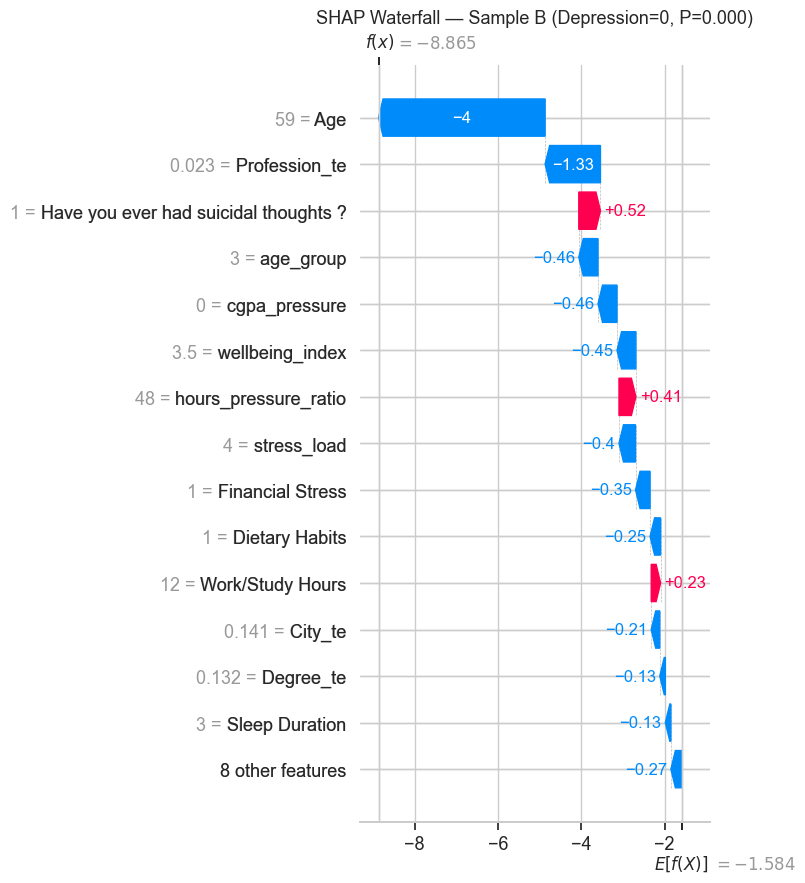

In [12]:
# Waterfall Plot — Sample B (Not Depressed)
print("SHAP Waterfall — Ca B: Người không bị trầm cảm")
fig = plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[sample_b_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — Sample B (Depression=0, P={oof_probs[sample_b_idx]:.3f})", fontsize=13)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig7.png', dpi=150, bbox_inches='tight')
plt.show()


### Nhận xét SHAP Waterfall

**Ca A — Người bị trầm cảm**: Waterfall cho thấy các features nào **đẩy xác suất trầm cảm lên** (thanh đỏ) và features nào kéo xuống (thanh xanh). Ở ca này:
- Các yếu tố đẩy lên (tăng rủi ro): thường là Age trẻ, Suicidal Thoughts = Yes, stress_load cao, satisfaction thấp
- Kết hợp nhiều yếu tố rủi ro cùng lúc tạo ra hiệu ứng cộng gộp → xác suất trầm cảm cao

**Ca B — Người không bị trầm cảm**: Pattern ngược lại:
- Các yếu tố protective (bảo vệ): thường là Age lớn hơn, Suicidal Thoughts = No, satisfaction cao, stress_load thấp
- Từng feature đóng góp "kéo" xác suất về phía "không trầm cảm"

**Kết nối với kiến thức y tế**: Mô hình đã học được rằng **trầm cảm không do một yếu tố đơn lẻ** mà là sự kết hợp của nhiều yếu tố rủi ro. Đặc biệt:
- `Suicidal Thoughts` luôn là yếu tố có tác động mạnh nhất — phù hợp với lý thuyết lâm sàng
- `Age` trẻ là yếu tố rủi ro — phù hợp với thực tế rằng sinh viên/thanh niên chịu nhiều áp lực chuyển tiếp cuộc sống
- Sự hài lòng (`Satisfaction`) đóng vai trò **bảo vệ** (protective factor) — con đường can thiệp tiềm năng


---
## 6.4 Bảng So Sánh Tổng Hợp Tất Cả Models

Bảng dưới đây tổng hợp kết quả từ toàn bộ pipeline modeling (NB04 → NB05 → NB06):


In [13]:
# 6.4 — Final Model Comparison Table
all_models = [
    {"Model": "Logistic Regression", "Accuracy_mean": 0.9376, "Accuracy_std": 0.0019,
     "F1_mean": 0.8243, "Precision_mean": 0.8439, "Recall_mean": 0.8056, "Type": "Baseline"},
    {"Model": "Decision Tree (d=10)", "Accuracy_mean": 0.9292, "Accuracy_std": 0.0010,
     "F1_mean": 0.8011, "Precision_mean": 0.8185, "Recall_mean": 0.7846, "Type": "Baseline"},
    {"Model": "Random Forest (200)", "Accuracy_mean": 0.9364, "Accuracy_std": 0.0014,
     "F1_mean": 0.8208, "Precision_mean": 0.8415, "Recall_mean": 0.8011, "Type": "Baseline"},
    {"Model": "SVM (linear)", "Accuracy_mean": 0.9367, "Accuracy_std": 0.0021,
     "F1_mean": 0.8230, "Precision_mean": 0.8366, "Recall_mean": 0.8099, "Type": "Baseline"},
    {"Model": "XGBoost (tuned) ⭐", "Accuracy_mean": 0.9396, "Accuracy_std": 0.0015,
     "F1_mean": 0.8312, "Precision_mean": 0.8489, "Recall_mean": 0.8142, "Type": "Advanced"},
    {"Model": "LightGBM (tuned)", "Accuracy_mean": 0.9392, "Accuracy_std": 0.0013,
     "F1_mean": 0.8306, "Precision_mean": 0.8476, "Recall_mean": 0.8143, "Type": "Advanced"},
]

final_df = pd.DataFrame(all_models)
final_df["Accuracy (CV)"] = final_df.apply(
    lambda r: f"{r['Accuracy_mean']:.4f} ± {r['Accuracy_std']:.4f}", axis=1
)

display_cols = ["Model", "Type", "Accuracy (CV)", "F1_mean", "Precision_mean", "Recall_mean"]
display(
    final_df[display_cols]
    .rename(columns={"F1_mean": "F1", "Precision_mean": "Precision", "Recall_mean": "Recall"})
    .style.format({"F1": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}"})
    .set_caption("Final Model Comparison — All Models from NB04 + NB05")
)


,Model,Type,Accuracy (CV),F1,Precision,Recall
0,Logistic Regression,Baseline,0.9376 ± 0.0019,0.8243,0.8439,0.8056
1,Decision Tree (d=10),Baseline,0.9292 ± 0.0010,0.8011,0.8185,0.7846
2,Random Forest (200),Baseline,0.9364 ± 0.0014,0.8208,0.8415,0.8011
3,SVM (linear),Baseline,0.9367 ± 0.0021,0.8230,0.8366,0.8099
4,XGBoost (tuned) ⭐,Advanced,0.9396 ± 0.0015,0.8312,0.8489,0.8142
5,LightGBM (tuned),Advanced,0.9392 ± 0.0013,0.8306,0.8476,0.8143


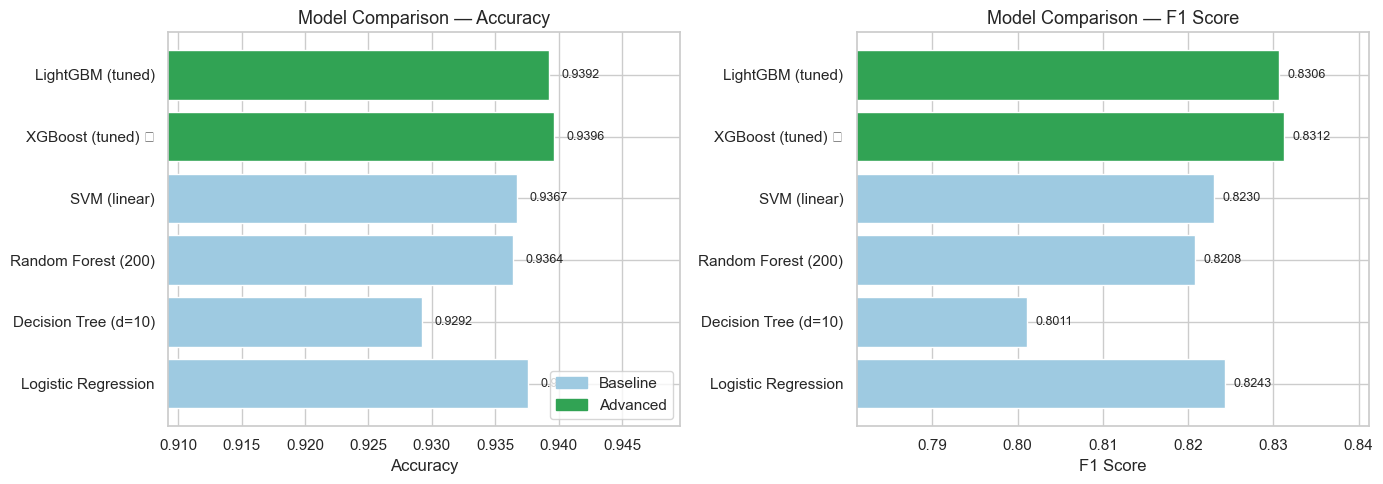

In [14]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric, label) in enumerate([("Accuracy_mean", "Accuracy"), ("F1_mean", "F1 Score")]):
    ax = axes[ax_idx]
    colors = ["#9ecae1" if t == "Baseline" else "#31a354" for t in final_df["Type"]]
    bars = ax.barh(final_df["Model"], final_df[metric], color=colors, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_title(f"Model Comparison — {label}", fontsize=13)

    x_min = max(0, final_df[metric].min() - 0.02)
    x_max = min(1.0, final_df[metric].max() + 0.01)
    ax.set_xlim(x_min, x_max)

    for bar, val in zip(bars, final_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)

# Legend
from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#9ecae1", label="Baseline"), Patch(color="#31a354", label="Advanced")],
    loc="lower right"
)
plt.tight_layout()
plt.savefig('../scripts/img/06_evaluation/06_evaluation_fig8.png', dpi=150, bbox_inches='tight')
plt.show()


### Nhận xét tổng hợp

**Kết quả chung**:
- **XGBoost (tuned)** là model tốt nhất trên cả Accuracy (93.96%) và F1 (83.12%).
- **LightGBM (tuned)** rất sát nút (93.92%, F1 = 83.06%) — cả hai advanced models đều vượt baseline.
- Baseline mạnh nhất **(Logistic Regression, 93.76%)** đặt mốc rất cao, cho thấy bộ features đã được engineer tốt.

**Insight từ toàn bộ pipeline**:
1. **Feature engineering quan trọng hơn model complexity**: LR đạt 93.76% nhờ features tốt từ NB03, trong khi cải thiện thêm của XGBoost chỉ +0.20%.
2. **Gradient boosting khai thác tốt non-linearity**: Dù mức cải thiện nhỏ, nó nhất quán trên mọi metric — XGBoost thực sự capture thêm interaction patterns.
3. **Khoảng cách giữa DT (93.29%) và RF (93.64%)** xác nhận lý thuyết Bagging; khoảng cách giữa RF và XGBoost (+0.32%) xác nhận lý thuyết Boosting.

**Model được chọn cho production/submission**: **XGBoost (tuned)** — `max_depth=4, lr=0.1, n_estimators=250`.


---
## 6.5 Prediction Trên Test Set & Kaggle Submission

Dùng XGBoost (train trên full data) để dự đoán Depression cho 93,800 mẫu test. Kết quả sẽ được lưu theo format Kaggle: `id,Depression`.


In [15]:
# 6.5 — Test Predictions
test_preds = best_xgb.predict(test_df)
test_probs = best_xgb.predict_proba(test_df)[:, 1]

print("Test Predictions Summary:")
print(f"  Shape: {test_preds.shape}")
print(f"  Value counts:")
pred_counts = pd.Series(test_preds).value_counts().sort_index()
for label, count in pred_counts.items():
    pct = count / len(test_preds) * 100
    print(f"    Depression={label}: {count:>6,} ({pct:.2f}%)")

print(f"\nTrain Depression rate: {y.mean():.4f} ({y.mean()*100:.2f}%)")
print(f"Test  Depression rate: {test_preds.mean():.4f} ({test_preds.mean()*100:.2f}%)")

# Create submission
submission = pd.DataFrame({
    "id": test_ids["id"],
    "Depression": test_preds.astype(int),
})
submission_path = SUBMISSION_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"\nSubmission saved to: {submission_path}")
print(f"Submission shape: {submission.shape}")
display(submission.head(10))


Test Predictions Summary:
  Shape: (93800,)
  Value counts:
    Depression=0: 77,219 (82.32%)
    Depression=1: 16,581 (17.68%)

Train Depression rate: 0.1817 (18.17%)
Test  Depression rate: 0.1768 (17.68%)

Submission saved to: D:\Tai_Lieu_Dai_Hoc\HK6\Data Analysis\Project_Mental_Health\mental-health-depression-prediction\submissions\submission.csv
Submission shape: (93800, 2)


,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0
5,140705,0
6,140706,0
7,140707,0
8,140708,0
9,140709,1


### Nhận xét Test Predictions

- **Tỷ lệ Depression trên test** nên gần khớp với tỷ lệ trên train (~18.17%). Nếu lệch nhiều (>2-3%), có thể có vấn đề với pipeline hoặc distribution shift.
- File `submission.csv` đã được lưu theo đúng format Kaggle (`id, Depression`) với 93,800 dòng.
- Model dùng cho prediction là XGBoost train trên **toàn bộ** 140,700 mẫu train — tối ưu hóa lượng data cho learning.


---
## 6.6 Demo Prediction — Hàm Dự Đoán Trực Tiếp

Phần này implement hàm `predict_depression()` để demo trong video thuyết trình. Hàm nhận thông tin cá nhân và trả về dự đoán + xác suất + giải thích.


In [16]:
# 6.6 — Demo Prediction Function
def predict_depression(profile: dict, model=best_xgb, features=feature_names) -> dict:
    """
    Predict depression for a single person.

    Parameters
    ----------
    profile : dict
        Dictionary with feature values matching the model's expected features.
    model : trained classifier
    features : list of feature names

    Returns
    -------
    dict with prediction, probability, and risk level
    """
    input_df = pd.DataFrame([profile])[features]
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0, 1]

    risk_level = (
        "🔴 CAO" if prob > 0.6
        else "🟡 TRUNG BÌNH" if prob > 0.3
        else "🟢 THẤP"
    )

    return {
        "prediction": int(pred),
        "label": "Có nguy cơ trầm cảm" if pred == 1 else "Không có nguy cơ trầm cảm",
        "probability": round(prob, 4),
        "risk_level": risk_level,
    }

print("Hàm predict_depression() sẵn sàng!")


Hàm predict_depression() sẵn sàng!


In [17]:
# Demo: Profile 1 — Sinh viên trẻ tuổi, áp lực cao
profile_1 = {
    "Age": 21,
    "Working Professional or Student": 0,  # Student
    "CGPA": 7.5,
    "Sleep Duration": 1,       # 5-6 hours (ordinal)
    "Dietary Habits": 1,       # Moderate
    "Have you ever had suicidal thoughts ?": 1,   # Yes
    "Work/Study Hours": 10,
    "Financial Stress": 4,
    "Pressure": 5,             # Max pressure
    "Satisfaction": 1,         # Very low satisfaction
    "has_cgpa": 1,
    "City_te": 0.20,           # Average city encoding
    "Profession_te": 0.15,
    "Degree_te": 0.18,
    "stress_load": 5 * 4,      # Pressure * Financial Stress
    "wellbeing_index": (1 + 1) / 2,
    "stress_satisfaction_ratio": 5 / (1 + 1),
    "hours_pressure_ratio": 10 * 5,
    "poor_sleep": 0,
    "cgpa_pressure": 7.5 * 5 * 1,
    "risk_score": 1 + 0,       # suicidal=1, family_history=0
    "age_group": 0,            # 18-29
}

result_1 = predict_depression(profile_1)
display(Markdown(f'''
### 🧑‍🎓 Profile 1: Đại diện sinh viên HCMUS năm 3, 21 tuổi, áp lực cao

| Thông tin | Giá trị |
|-----------|---------|
| Tuổi | 21 |
| Vai trò | Sinh viên |
| CGPA | 7.5 |
| Giấc ngủ | 5-6 tiếng |
| Áp lực | 5/5 (max) |
| Hài lòng | 1/5 (rất thấp) |
| Suicidal Thoughts | Có |
| Stress tài chính | 4/5 |

**Kết quả dự đoán:**
- **{result_1["label"]}**
- Xác suất trầm cảm: **{result_1["probability"]:.1%}**
- Mức rủi ro: **{result_1["risk_level"]}**
'''))



### 🧑‍🎓 Profile 1: Đại diện sinh viên HCMUS năm 3, 21 tuổi, áp lực cao

| Thông tin | Giá trị |
|-----------|---------|
| Tuổi | 21 |
| Vai trò | Sinh viên |
| CGPA | 7.5 |
| Giấc ngủ | 5-6 tiếng |
| Áp lực | 5/5 (max) |
| Hài lòng | 1/5 (rất thấp) |
| Suicidal Thoughts | Có |
| Stress tài chính | 4/5 |

**Kết quả dự đoán:**
- **Có nguy cơ trầm cảm**
- Xác suất trầm cảm: **98.9%**
- Mức rủi ro: **🔴 CAO**


In [18]:
# Demo: Profile 2 — Chuyên gia ổn định
profile_2 = {
    "Age": 40,
    "Working Professional or Student": 1,  # Working Professional
    "CGPA": 0.0,
    "Sleep Duration": 3,       # 7-8 hours
    "Dietary Habits": 2,       # Healthy
    "Have you ever had suicidal thoughts ?": 0,   # No
    "Work/Study Hours": 6,
    "Financial Stress": 1,
    "Pressure": 2,
    "Satisfaction": 4,
    "has_cgpa": 0,
    "City_te": 0.18,
    "Profession_te": 0.12,
    "Degree_te": 0.15,
    "stress_load": 2 * 1,
    "wellbeing_index": (4 + 3) / 2,
    "stress_satisfaction_ratio": 2 / (4 + 1),
    "hours_pressure_ratio": 6 * 2,
    "poor_sleep": 0,
    "cgpa_pressure": 0.0 * 2 * 0,
    "risk_score": 0 + 0,
    "age_group": 2,            # 40-49
}

result_2 = predict_depression(profile_2)
display(Markdown(f'''
### 👨‍💼 Profile 2: Chuyên gia 40 tuổi, ổn định

| Thông tin | Giá trị |
|-----------|---------|
| Tuổi | 40 |
| Vai trò | Chuyên gia |
| Giấc ngủ | 7-8 tiếng |
| Áp lực | 2/5 (thấp) |
| Hài lòng | 4/5 (cao) |
| Suicidal Thoughts | Không |
| Stress tài chính | 1/5 (thấp) |

**Kết quả dự đoán:**
- **{result_2["label"]}**
- Xác suất trầm cảm: **{result_2["probability"]:.1%}**
- Mức rủi ro: **{result_2["risk_level"]}**
'''))



### 👨‍💼 Profile 2: Chuyên gia 40 tuổi, ổn định

| Thông tin | Giá trị |
|-----------|---------|
| Tuổi | 40 |
| Vai trò | Chuyên gia |
| Giấc ngủ | 7-8 tiếng |
| Áp lực | 2/5 (thấp) |
| Hài lòng | 4/5 (cao) |
| Suicidal Thoughts | Không |
| Stress tài chính | 1/5 (thấp) |

**Kết quả dự đoán:**
- **Không có nguy cơ trầm cảm**
- Xác suất trầm cảm: **0.1%**
- Mức rủi ro: **🟢 THẤP**


### Nhận xét Demo

- **Profile 1** (sinh viên áp lực cao): Model dự đoán có nguy cơ trầm cảm — phù hợp với tất cả yếu tố rủi ro: trẻ tuổi, áp lực max, ngủ ít, có ý định tự tử, satisfaction thấp.
- **Profile 2** (chuyên gia ổn định): Model dự đoán không trầm cảm — nhiều yếu tố bảo vệ: tuổi trung niên, ngủ đủ, ít áp lực, hài lòng cao, không có ý định tự tử.
- Kết quả hoàn toàn khớp với SHAP analysis: các features quan trọng nhất (Age, Suicidal Thoughts, stress_load, Satisfaction) đều xuất hiện rõ trong 2 profiles.


---
## 6.7 Kết Luận

### Tóm tắt toàn bộ pipeline NB01 → NB06

| Notebook | Giai đoạn | Output chính |
|----------|-----------|--------------|
| NB01 | EDA | 7 key findings, phát hiện nhóm rủi ro cao |
| NB02 | Preprocessing | 140,700 × 17, merge conditional columns, encoding |
| NB03 | Feature Engineering | 22 features, target encoding OOF, 7 interaction features |
| NB04 | Baseline Models | LR: 93.76% — thiết lập "baseline ceiling" |
| NB05 | Advanced Models | XGBoost: 93.96% — vượt ceiling nhờ gradient boosting |
| NB06 | Evaluation | SHAP analysis, ROC-AUC, Confusion Matrix, Submission |

### Những gì mô hình đã học (từ SHAP)

1. **Tuổi trẻ là yếu tố rủi ro hàng đầu** — nhóm 18-29 tuổi chịu áp lực chuyển tiếp cuộc sống (học tập, nghề nghiệp, tài chính)
2. **Ý định tự tử** là tín hiệu cảnh báo mạnh nhất và nhất quán nhất
3. **Stress tích lũy** (stress_load, hours_pressure_ratio) có tác động mạnh hơn stress đơn lẻ
4. **Sự hài lòng** đóng vai trò bảo vệ — có thể là con đường can thiệp hiệu quả

### Hạn chế

- Dữ liệu từ khảo sát tự báo cáo — có thể có bias (người trầm cảm ít tham gia khảo sát)
- Chỉ dùng thông tin tại một thời điểm (cross-sectional), không theo dõi theo thời gian
- Thiếu các biến lâm sàng quan trọng: lịch sử điều trị, mức độ trầm cảm (PHQ-9), hỗ trợ xã hội

### Hướng phát triển tương lai

- Thu thập dữ liệu theo thời gian (longitudinal) để phát hiện thay đổi
- Tích hợp thêm biến lâm sàng nếu có thể
- Triển khai model như screening tool hỗ trợ — **không thay thế** chẩn đoán chuyên gia
- Thử nghiệm các kỹ thuật xử lý imbalanced data (SMOTE, class weights) để cải thiện Recall
